In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/rml201610b/RML2016.10b.dat


In [4]:
# ============================================================
# Kaggle-ready SC-CTN (Keras) for RadioML 2016.10b on GPU P100
# ============================================================

!nvidia-smi -L

import os, pickle, math, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ---------------------------
# 0) Performance settings
# ---------------------------
# Enable XLA and mixed precision for P100
tf.config.optimizer.set_jit(True)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")

# Optional: deterministic
# tf.config.experimental.enable_op_determinism()


GPU 0: Tesla P100-PCIE-16GB (UUID: GPU-c78a0026-ee7f-9d41-9541-91f4e5b6b6aa)


/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [5]:
import os, pickle, math, numpy as np, tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

# =========================================================
# 1) Load RML2016.10a (robust loader)
# =========================================================

import os, pickle, numpy as np, tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import StratifiedShuffleSplit

# ====================================================
# Load RadioML 2016.10A or 2016.10B in a unified way
# ====================================================
DATA_PATH = "/kaggle/input/rml201610b/RML2016.10b.dat"   # <--- change to your 10B file
# e.g. ".../RML2016.10b.dat" depending on filename

with open(DATA_PATH, "rb") as f:
    raw = pickle.load(f, encoding="latin1")

def load_rml2016_any(obj):
    """
    Works for:
      - 2016.10A dict[(mod, snr)] = array(N, 2, 128)
      - 2016.10B dict[(mod, snr)] = array(N, 2, 128)
      - Or a dict {"X":..., "Y":..., "SNR":...}
    """
    # Case 1: dict with explicit X/Y/SNR keys
    if isinstance(obj, dict) and all(k in obj for k in ["X","Y","SNR"]):
        X = np.asarray(obj["X"], dtype="float32")
        Y = np.asarray(obj["Y"], dtype="int32")
        SNR = np.asarray(obj["SNR"], dtype="float32")
        return X, Y, SNR

    # Case 2: dict keyed by (mod_label, snr) — typical 2016.10A/10B format
    if isinstance(obj, dict):
        mods = sorted({k[0] for k in obj.keys()})
        snrs = sorted({k[1] for k in obj.keys()})
        print("Detected mods:", mods)
        print("Detected SNRs:", snrs)

        X_list, Y_list, SNR_list = [], [], []
        for mod in mods:
            for snr in snrs:
                key = (mod, snr)
                if key not in obj:
                    continue
                block = obj[key]  # shape: (N_i, 2, 128)
                X_list.append(block)
                Y_list.extend([mods.index(mod)] * block.shape[0])
                SNR_list.extend([snr] * block.shape[0])

        X = np.vstack(X_list).astype("float32")   # (N, 2, 128)
        Y = np.array(Y_list, dtype="int32")       # (N,)
        SNR = np.array(SNR_list, dtype="float32") # (N,)
        return X, Y, SNR

    raise ValueError("Unrecognized RML2016 object format")

X, Y, SNR = load_rml2016_any(raw)
print("Raw shapes -> X:", X.shape, "Y:", Y.shape, "SNR:", SNR.shape)

# Keras expects (N, T, C) = (N, 128, 2)
X = np.transpose(X, (0, 2, 1)).astype("float32")   # (N, 128, 2)

NUM_CLASSES = int(np.max(Y) + 1)
print("NUM_CLASSES:", NUM_CLASSES)    # 2016.10B => should be 26
Yint = Y.astype("int32")
Yoh = keras.utils.to_categorical(Yint, NUM_CLASSES).astype("float32")
SNRdb = SNR.astype("float32").reshape(-1, 1)

# =========================================================
# 2) Precision policy (start stable)
# =========================================================

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("float32")  # switch to "mixed_float16" later if stable

def _safe_eps(x, f16_eps=1e-4, f32_eps=1e-12):
    return tf.constant(f16_eps if x.dtype == tf.float16 else f32_eps, dtype=x.dtype)

def snr_embed(snr, d=32, name="snr_mlp"):
    x = layers.Dense(32, activation="relu", name=name+"_d1")(snr)
    x = layers.Dense(d,  activation="relu", name=name+"_d2")(x)
    return x

def bn32(name):
    return layers.BatchNormalization(momentum=0.99, epsilon=1e-4, dtype="float32", name=name)

def cast_back(x):
    # Cast BN output back to compute dtype (currently float32, later maybe float16)
    return tf.cast(x, tf.keras.mixed_precision.global_policy().compute_dtype)

# =========================================================
# 3) Custom Layers
# =========================================================

@keras.utils.register_keras_serializable(package="rf")
class ComplexConv1DNRBi(layers.Layer):
    """
    Complex 1D conv on IQ + SNR-conditioned soft-threshold shrinkage on magnitude,
    followed by a BiLSTM over time.

    Input:  x_iq  : (B, T, 2)
            snr_cond: (B, D) or None
    Output: (B, T, 2 * lstm_units)  (default lstm_units = filters, so shape stays (B,T,2*filters))
    """
    def __init__(
        self,
        filters,
        kernel_size=7,
        strides=1,
        padding="same",
        cond_dim=32,
        lstm_units=None,
        **kw
    ):
        super().__init__(**kw)
        self.filters     = int(filters)
        self.kernel_size = int(kernel_size)
        self.strides     = int(strides)
        self.padding     = padding
        self.cond_dim    = int(cond_dim)
        self.lstm_units  = int(lstm_units) if lstm_units is not None else int(filters)

        # complex conv (real + imag parts)
        self.conv_r = layers.Conv1D(
            self.filters,
            self.kernel_size,
            strides=self.strides,
            padding=self.padding,
            use_bias=False,
        )
        self.conv_i = layers.Conv1D(
            self.filters,
            self.kernel_size,
            strides=self.strides,
            padding=self.padding,
            use_bias=False,
        )

        # BN in float32 for stability
        self.bn = bn32(self.name + "_bn")

        # SNR-conditioned threshold MLP
        self.th_mlp = keras.Sequential(
            [
                layers.Dense(self.filters, activation="relu"),
                layers.Dense(self.filters, activation="softplus"),
            ],
            name=self.name + "_thr",
        )

        # BiLSTM over time (T dimension)
        self.bilstm = layers.Bidirectional(
            layers.LSTM(self.lstm_units, return_sequences=True),
            name=self.name + "_bilstm",
        )

    def call(self, x_iq, snr_cond=None, training=None):
        # ---- complex conv ----
        I, Q = x_iq[..., 0:1], x_iq[..., 1:2]      # (B,T,1)
        real = self.conv_r(I) - self.conv_i(Q)     # (B,T,F)
        imag = self.conv_r(Q) + self.conv_i(I)     # (B,T,F)
        x = tf.concat([real, imag], axis=-1)       # (B,T,2F)

        # ---- BN + ReLU ----
        x = self.bn(x, training=training)
        x = cast_back(x)
        x = keras.activations.relu(x)

        # ---- magnitude shrinkage (SNR-aware) ----
        C = x.shape[-1] // 2
        xr, xi = x[..., :C], x[..., C:]
        mag = tf.sqrt(tf.maximum(xr * xr + xi * xi, _safe_eps(xr)))  # (B,T,F)

        if snr_cond is None:
            thr = tf.reshape(tf.cast(0.05, x.dtype), [1, 1, 1])
            scale = tf.nn.relu(mag - thr) / (mag + _safe_eps(mag))
        else:
            t = self.th_mlp(snr_cond)                          # (B,F)
            t = tf.expand_dims(tf.cast(t, x.dtype), 1)         # (B,1,F)
            scale = tf.nn.relu(mag - t) / (mag + _safe_eps(mag))

        xr = xr * scale
        xi = xi * scale
        x  = tf.concat([xr, xi], axis=-1)                      # (B,T,2F)

        # ---- BiLSTM over time ----
        x = self.bilstm(x)  # (B,T, 2 * lstm_units)

        return x

    def get_config(self):
        config = {
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "strides": self.strides,
            "padding": self.padding,
            "cond_dim": self.cond_dim,
            "lstm_units": self.lstm_units,
        }
        base_config = super().get_config()
        return {**base_config, **config}


@keras.utils.register_keras_serializable(package="rf")
class NoiseAdaptiveSE1D(layers.Layer):
    """Squeeze-Excite with trimmed-mean & SNR-temperature."""
    def __init__(self, channels, reduction=8, cond_dim=32, trim=0.1, **kw):
        super().__init__(**kw)
        self.channels  = int(channels)
        self.reduction = int(reduction)
        self.trim      = float(trim)
        self.fc1 = layers.Dense(self.channels // self.reduction, activation="relu")
        self.fc2 = layers.Dense(self.channels, activation=None)
        self.temp_mlp = keras.Sequential([
            layers.Dense(16, activation="relu"),
            layers.Dense(1, activation="softplus")
        ], name=self.name + "_temp")

    @staticmethod
    def trimmed_mean(x, trim=0.1, axis=1):
        k = tf.shape(x)[axis]
        lo = tf.cast(tf.round(trim * tf.cast(k, tf.float32)), tf.int32)
        hi = k - lo
        x_sorted = tf.sort(x, axis=axis)
        idx = tf.range(lo, hi)
        x_trim = tf.gather(x_sorted, idx, axis=axis)
        return tf.reduce_mean(x_trim, axis=axis)

    def call(self, x, snr_cond=None):
        xm = self.trimmed_mean(x, trim=self.trim, axis=1)  # (B,C)
        z  = self.fc1(xm)
        z  = self.fc2(z)                                   # (B,C)
        if snr_cond is not None:
            tau = self.temp_mlp(snr_cond) + tf.cast(0.5, z.dtype)  # (B,1)
            tau = tf.maximum(tau, _safe_eps(z))
            z = z / tau
        g = tf.nn.sigmoid(z)                               # (B,C)
        return x * g[:, None, :]

@keras.utils.register_keras_serializable(package="rf")
class NoiseConditionedFiLM(layers.Layer):
    """FiLM with bounded gain."""
    def __init__(self, channels, cond_dim, max_gain=0.5, **kw):
        super().__init__(**kw)
        self.channels = int(channels)
        self.max_gain = float(max_gain)
        self.gamma = layers.Dense(self.channels)
        self.beta  = layers.Dense(self.channels)

    def call(self, x, cond):
        g = tf.tanh(self.gamma(cond)) * self.max_gain     # (B,C)
        b = self.beta(cond)                               # (B,C)
        g = g[:, None, :]
        b = b[:, None, :]
        return x * (1.0 + g) + b

@keras.utils.register_keras_serializable(package="rf")
class NoiseAwareTransformer(layers.Layer):
    """MHA + FFN with depthwise denoise + SNR scaling."""
    def __init__(self, num_heads=4, key_dim=32, ff_dim=256, rate=0.1, **kw):
        super().__init__(**kw)
        self.mha  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=key_dim,
                                              dropout=rate, name=self.name+"_mha")
        self.ln1  = layers.LayerNormalization(epsilon=1e-5, name=self.name+"_ln1")
        self.ff1  = layers.Dense(ff_dim, activation="relu", name=self.name+"_ff1")
        self.drop = layers.Dropout(rate)
        self.ln2  = layers.LayerNormalization(epsilon=1e-5, name=self.name+"_ln2")
        self.temp_mlp = keras.Sequential([
            layers.Dense(16, activation="relu"),
            layers.Dense(1, activation="softplus")
        ], name=self.name + "_temp")
        self._ff2 = None
        self._dw  = None

    def build(self, input_shape):
        C = input_shape[-1]
        self._ff2 = layers.Dense(C, name=self.name+"_ff2")
        self._dw  = layers.SeparableConv1D(filters=C, kernel_size=5,
                                           padding="same", name=self.name+"_dw")

    def call(self, x, snr_cond=None, training=None):
        y = self._dw(x)
        if snr_cond is None:
            tau = tf.cast(1.0, y.dtype)
        else:
            tau = self.temp_mlp(snr_cond) + tf.cast(0.5, y.dtype)  # (B,1)
            tau = tf.maximum(tau, _safe_eps(y))
        scale = tf.math.rsqrt(tau)
        y = y * scale[:, None, :]

        attn = self.mha(y, y, training=training)
        x = self.ln1(x + attn)
        ff = self.ff1(x)
        ff = self.drop(ff, training=training)
        ff = self._ff2(ff)
        x = self.ln2(x + ff)
        return x

# =========================================================
# 4) Stem & Blocks
# =========================================================

@keras.utils.register_keras_serializable(package="rf")
class LowSNRStem(layers.Layer):
    def __init__(self, out_channels=64, cond_dim=32, **kw):
        super().__init__(**kw)
        self.cc   = ComplexConv1DNRBi(filters=out_channels//2, kernel_size=7,
                                    cond_dim=cond_dim, name=self.name+"_cc")
        self.bn   = bn32(self.name + "_bn")
        self.se   = NoiseAdaptiveSE1D(out_channels, reduction=8,
                                      cond_dim=cond_dim, trim=0.1, name=self.name+"_se")
        self.film = NoiseConditionedFiLM(out_channels, cond_dim=cond_dim,
                                         max_gain=0.5, name=self.name+"_film")
        self.tr   = NoiseAwareTransformer(num_heads=4, key_dim=32,
                                          ff_dim=2*out_channels, rate=0.1,
                                          name=self.name+"_tr")

    def call(self, iq, cond, training=None):
        x = self.cc(iq, snr_cond=cond, training=training)
        x = self.bn(x, training=training); x = cast_back(x)
        x = keras.activations.relu(x)
        x = self.se(x, cond)
        x = self.film(x, cond)
        x = self.tr(x, cond, training=training)
        return x

@keras.utils.register_keras_serializable(package="rf")
class LowSNRBlockFeat(layers.Layer):
    def __init__(self, out_channels=128, cond_dim=32, **kw):
        super().__init__(**kw)
        self.proj = layers.Conv1D(out_channels, 1, padding="same",
                                  name=self.name+"_proj")
        self.bn   = bn32(self.name + "_bn")
        self.se   = NoiseAdaptiveSE1D(out_channels, reduction=8,
                                      cond_dim=cond_dim, trim=0.1, name=self.name+"_se")
        self.film = NoiseConditionedFiLM(out_channels, cond_dim=cond_dim,
                                         max_gain=0.5, name=self.name+"_film")
        self.dw1  = layers.DepthwiseConv1D(5, dilation_rate=2,
                                           padding="same", name=self.name+"_dw1")
        self.pw1  = layers.Conv1D(out_channels, 1, padding="same",
                                  name=self.name+"_pw1")
        self.tr   = NoiseAwareTransformer(num_heads=4, key_dim=32,
                                          ff_dim=2*out_channels, rate=0.1,
                                          name=self.name+"_tr")

    def call(self, x, cond, training=None):
        y = self.proj(x)
        y = self.bn(y, training=training); y = cast_back(y)
        y = keras.activations.relu(y)
        y = self.se(y, cond)
        y = self.film(y, cond)
        r = self.dw1(y)
        r = self.pw1(r)
        y = y + r
        y = self.tr(y, cond, training=training)
        return y

# =========================================================
# 5) Build model
# =========================================================

def build_low_snr_scctn(input_len=128, num_classes=11, cond_dim=32):
    iq_in  = keras.Input(shape=(input_len, 2), name="iq")
    snr_in = keras.Input(shape=(1,),          name="snr")
    cond   = snr_embed(snr_in, d=cond_dim, name="cond")

    x = LowSNRStem(out_channels=64,  cond_dim=cond_dim, name="stem")(iq_in, cond)
    x = LowSNRBlockFeat(out_channels=128, cond_dim=cond_dim, name="blk1")(x, cond)
    x = LowSNRBlockFeat(out_channels=128, cond_dim=cond_dim, name="blk2")(x, cond)

    gap = layers.GlobalAveragePooling1D(name="gap")(x)

    h = layers.Dense(256, activation="relu")(gap)
    h = layers.Dropout(0.2)(h)
    mod_out = layers.Dense(num_classes, activation="softmax",
                           dtype="float32", name="mod_out")(h)

    s = layers.Dense(64, activation="relu")(gap)
    snr_out = layers.Dense(1, dtype="float32", name="snr_out")(s)

    return keras.Model(inputs=[iq_in, snr_in],
                       outputs=[mod_out, snr_out],
                       name="LowSNR_SCCTN")

# =========================================================
# 6) Balanced class+SNR dataset
# =========================================================

def make_balanced_class_snr_dataset(
    X, Y, SNR_vec, batch=512, num_classes=None,
    augment=True, shuffle=True
):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y)
    SNR_vec = np.asarray(SNR_vec, dtype=np.float32)

    # labels: int or one-hot
    if Y.ndim == 1:
        y_int = Y.astype(np.int64)
        if num_classes is None:
            num_classes = int(np.max(y_int)) + 1
        Y_oh = keras.utils.to_categorical(y_int, num_classes).astype(np.float32)
    elif Y.ndim == 2:
        Y_oh = Y.astype(np.float32)
        if num_classes is None:
            num_classes = Y_oh.shape[1]
        y_int = np.argmax(Y_oh, axis=1).astype(np.int64)
    else:
        raise ValueError("Y must be (N,) or (N,K)")

    # SNR shape
    if SNR_vec.ndim == 1:
        SNR_vec = SNR_vec[:, None]
    elif not (SNR_vec.ndim == 2 and SNR_vec.shape[1] == 1):
        raise ValueError("SNR_vec must be (N,) or (N,1)")
    SNR_vec = np.clip(SNR_vec, -40.0, 40.0).astype(np.float32)

    # SNR buckets
    def snr_bucket(v):
        if v <= -10: return 0
        elif v <= 0: return 1
        elif v <= 6: return 2
        else:        return 3

    buckets = {(c, b): [] for c in range(num_classes) for b in range(4)}
    for i, (c, s) in enumerate(zip(y_int, SNR_vec.squeeze())):
        buckets[(int(c), snr_bucket(float(s)))].append(i)

    per_cell = max(1, batch // (num_classes * 4))
    cells = list(buckets.keys())
    rng = np.random.RandomState(123)

    def gen():
        while True:
            idxs = []
            for cell in cells:
                pool = buckets[cell]
                if not pool:
                    pool = rng.randint(0, len(X), size=1).tolist()
                idxs += list(rng.choice(pool, size=per_cell, replace=True))
            if shuffle:
                rng.shuffle(idxs)
            idxs_arr = np.asarray(idxs[:batch], dtype=np.int64)
            xb = X[idxs_arr]
            yb = Y_oh[idxs_arr]
            sb = SNR_vec[idxs_arr]
            yield xb, yb, sb

    ds = tf.data.Dataset.from_generator(
        gen,
        output_signature=(
            tf.TensorSpec((None, X.shape[1], X.shape[2]), tf.float32),
            tf.TensorSpec((None, num_classes),            tf.float32),
            tf.TensorSpec((None, 1),                      tf.float32),
        )
    )

    def phase_rotate(x):
        th = tf.random.uniform((), -np.pi, np.pi, dtype=x.dtype)
        c, s = tf.cos(th), tf.sin(th)
        I, Q = x[..., 0], x[..., 1]
        return tf.stack([c*I - s*Q, s*I + c*Q], axis=-1)

    def map_aug(x, y, s):
        if augment:
            mask = tf.random.uniform((tf.shape(x)[0],), 0, 1) < 0.5
            x_aug = tf.map_fn(phase_rotate, x)
            x = tf.where(mask[:, None, None], x_aug, x)
        x = tf.where(tf.math.is_finite(x), x, tf.zeros_like(x))
        s = tf.clip_by_value(s, -40.0, 40.0)
        return ({"iq": x, "snr": s}, {"mod_out": y, "snr_out": s})

    return ds.map(map_aug, num_parallel_calls=tf.data.AUTOTUNE)\
             .prefetch(tf.data.AUTOTUNE)
def make_raw_val_dataset(X_va, Y_va, S_va, batch, num_classes):
    """
    Build a *non-balanced* validation dataset from raw arrays.
    - X_va : (N_val, T, 2) float32
    - Y_va : (N_val,) int labels OR (N_val, K) one-hot
    - S_va : (N_val,1) or (N_val,) SNR in dB

    Returns a tf.data.Dataset that yields:
        ({"iq": x_batch, "snr": s_batch}, {"mod_out": y_batch_onehot, "snr_out": s_batch})
    with NO repeat(), so each epoch evaluates on the full val set once.
    """
    X_va = np.asarray(X_va, dtype=np.float32)
    Y_va = np.asarray(Y_va)
    S_va = np.asarray(S_va, dtype=np.float32)

    # --- handle labels ---
    if Y_va.ndim == 1:
        # integer labels -> one-hot
        Y_va_oh = tf.keras.utils.to_categorical(Y_va.astype(np.int32), num_classes).astype(np.float32)
    elif Y_va.ndim == 2:
        # already one-hot
        Y_va_oh = Y_va.astype(np.float32)
    else:
        raise ValueError("Y_va must be shape (N,) or (N,K)")

    # --- handle SNR shape ---
    if S_va.ndim == 1:
        S_va = S_va[:, None]
    elif S_va.ndim == 2 and S_va.shape[1] == 1:
        pass
    else:
        raise ValueError("S_va must be shape (N,) or (N,1)")

    # build dataset
    ds = tf.data.Dataset.from_tensor_slices(
        (
            {"iq": X_va, "snr": S_va},
            {"mod_out": Y_va_oh, "snr_out": S_va},
        )
    )
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    # no .repeat() here → one pass per epoch
    return ds

# =========================================================
# 7) LR schedule
# =========================================================

@keras.utils.register_keras_serializable(package="sched")
class WarmupCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, warmup_steps, total_steps, name=None):
        super().__init__()
        self.base_lr = float(base_lr)
        self.warmup_steps = int(warmup_steps)
        self.total_steps  = int(total_steps)
        self.name = name or "WarmupCosine"

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        w = tf.cast(self.warmup_steps, tf.float32)
        T = tf.cast(self.total_steps, tf.float32)
        lr = tf.cast(self.base_lr, tf.float32)

        warm = lr * step / tf.maximum(1.0, w)
        progress = tf.clip_by_value((step - w) / tf.maximum(1.0, (T - w)), 0.0, 1.0)
        cosv = 0.5 * lr * (1.0 + tf.cos(math.pi * progress))
        return tf.where(step < w, warm, cosv)

    def get_config(self):
        return {
            "base_lr": self.base_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
            "name": self.name,
        }

# =========================================================
# 8) Train + Evaluate
# =========================================================

if __name__ == "__main__":
    # stratified split on labels
    from sklearn.model_selection import StratifiedShuffleSplit
    import numpy as np

# ------------------------------------------
# Joint stratification on (class, SNR bucket)
# ------------------------------------------

# 1) Make sure SNR is 1D: (N,)
    snr_vals = SNRdb.squeeze().astype(np.float32)   # SNR can be (N,) or (N,1)

# 2) Define SNR bins (you can change edges if you like)
#    Here we roughly isolate the critical low-SNR region.
    snr_edges = np.array([-20, -12, -6, -2, 2, 6, 10, 18], dtype=np.float32)
# digitize -> returns bin index in [1..len(edges)], we shift to [0..B-1]
    snr_bin = np.digitize(snr_vals, snr_edges, right=True)

    n_snr_bins = int(snr_bin.max() + 1)

# 3) Build joint label: each (mod, snr_bin) pair gets its own id
#    Y is integer labels in [0..NUM_CLASSES-1]
    joint_label = Y.astype(int) * n_snr_bins + snr_bin

# 4) First split: Train+Val vs Test (15% test)
    sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
    tr_idx, te_idx = next(sss1.split(X, joint_label))

# 5) Second split inside Train+Val: Train vs Val (20% of remaining for val)
    joint_tr = joint_label[tr_idx]
    sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    tr2_idx, va_idx = next(sss2.split(X[tr_idx], joint_tr))

# 6) Final subsets
    X_tr, Y_tr, S_tr = X[tr_idx][tr2_idx], Yoh[tr_idx][tr2_idx], SNRdb[tr_idx][tr2_idx]
    X_va, Y_va, S_va = X[tr_idx][va_idx],   Yoh[tr_idx][va_idx],   SNRdb[tr_idx][va_idx]
    X_te, Y_te, S_te = X[te_idx],           Yoh[te_idx],           SNRdb[te_idx]

    print("Train:", X_tr.shape, "Val:", X_va.shape, "Test:", X_te.shape)

    BATCH = 512
    K = NUM_CLASSES
# ---------- TRAIN: balanced (class + SNR) ----------
    train_ds = make_balanced_class_snr_dataset(
    X_tr, Y_tr, S_tr,
    batch=BATCH,
    num_classes=K,
    augment=True,
    shuffle=True,
    )

# only train needs .repeat()
    train_ds = train_ds.repeat().prefetch(tf.data.AUTOTUNE)

# ---------- VAL: raw / unchanged distribution ----------
    val_ds = make_raw_val_dataset(
    X_va,   # original validation IQ
    Y_va,   # original validation labels
    S_va,   # original validation SNR
    batch=BATCH,
    num_classes=K,
    )


    model = build_low_snr_scctn(input_len=X.shape[1], num_classes=NUM_CLASSES, cond_dim=32)

    model.summary()

    EPOCHS = 120
    steps_per_epoch = max(1, len(X_tr) // BATCH)
    val_steps       = max(1, len(X_va) // BATCH)
    total_steps     = steps_per_epoch * EPOCHS
    warmup_steps    = steps_per_epoch * 3

    lr_sched = WarmupCosine(base_lr=1e-3, warmup_steps=warmup_steps, total_steps=total_steps)

    try:
        import tensorflow_addons as tfa
        opt = tfa.optimizers.AdamW(learning_rate=lr_sched, weight_decay=1e-4, clipnorm=1.0)
    except Exception:
        opt = tf.keras.optimizers.Adam(learning_rate=lr_sched, clipnorm=1.0)

    model.compile(
        optimizer=opt,
        loss={
            "mod_out": keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
            "snr_out": keras.losses.MeanAbsoluteError(),
        },
        loss_weights={"mod_out": 1.0, "snr_out": 0.05},
        metrics={"mod_out": ["accuracy"]},
    )

    cbs = [
        keras.callbacks.EarlyStopping(
            monitor="val_mod_out_accuracy", mode="max",
            patience=20, restore_best_weights=True
        ),
        keras.callbacks.ModelCheckpoint(
            "best_low_snr_scctn.keras",
            monitor="val_mod_out_accuracy", mode="max",
            save_best_only=True
        ),
    ]


    train_steps = max(1, len(X_tr) // BATCH)   # because train_ds repeats

    history = model.fit(
    train_ds,
    epochs=EPOCHS,
    steps_per_epoch=train_steps,
    validation_data=val_ds,   # raw, unchanged val
    callbacks=cbs,
    verbose=1,
    )


    # ---------- Evaluation ----------
    preds = model.predict({"iq": X_te, "snr": S_te}, batch_size=BATCH, verbose=0)
    if isinstance(preds, (list, tuple)):
        pred_mod = preds[0]
    else:
        pred_mod = preds

    y_pred = np.argmax(pred_mod, axis=1)

    # Y_te is int labels
    y_true = Y_te.astype(int)
    y_pred = y_pred.astype(int)

    acc = (y_pred == y_true).mean()
    print(f"\n[TEST] Accuracy: {acc*100:.2f}%")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    # Accuracy vs SNR
    snr_levels = np.unique(S_te.squeeze())
    print("\nAccuracy vs SNR:")
    for s in sorted(snr_levels):
        mask = np.isclose(S_te.squeeze(), s)
        if mask.sum() == 0:
            continue
        snr_acc = (y_pred[mask] == y_true[mask]).mean()
        print(f"SNR {int(s):>3} dB : {snr_acc*100:5.2f}%")


Detected mods: ['8PSK', 'AM-DSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
Detected SNRs: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Raw shapes -> X: (1200000, 2, 128) Y: (1200000,) SNR: (1200000,)
NUM_CLASSES: 10
Train: (816000, 128, 2) Val: (204000, 128, 2) Test: (180000, 128, 2)
Model: "LowSNR_SCCTN"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 snr (InputLayer)               [(None, 1)]          0           []                               
                                                                                                  
 cond_d1 (Dense)                (None, 32)           64          ['snr[0][0]']                    
                                                                                                  
 iq (InputLayer)                [(No

/opt/conda/lib/python3.10/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


Epoch 1/120
1593/1593 [==============================] - 404s 220ms/step - loss: 1.6864 - mod_out_loss: 1.6058 - snr_out_loss: 1.6103 - mod_out_accuracy: 0.3881 - val_loss: 1.2786 - val_mod_out_loss: 1.2644 - val_snr_out_loss: 0.2839 - val_mod_out_accuracy: 0.5243
Epoch 2/120
1593/1593 [==============================] - 344s 216ms/step - loss: 1.0912 - mod_out_loss: 1.0814 - snr_out_loss: 0.1957 - mod_out_accuracy: 0.6099 - val_loss: 1.1181 - val_mod_out_loss: 1.1106 - val_snr_out_loss: 0.1499 - val_mod_out_accuracy: 0.6086
Epoch 3/120
1593/1593 [==============================] - 340s 213ms/step - loss: 1.0137 - mod_out_loss: 1.0044 - snr_out_loss: 0.1862 - mod_out_accuracy: 0.6520 - val_loss: 1.0708 - val_mod_out_loss: 1.0632 - val_snr_out_loss: 0.1524 - val_mod_out_accuracy: 0.6352
Epoch 4/120
1593/1593 [==============================] - 341s 214ms/step - loss: 0.9624 - mod_out_loss: 0.9543 - snr_out_loss: 0.1620 - mod_out_accuracy: 0.6875 - val_loss: 1.1027 - val_mod_out_loss: 1.094

/tmp/ipykernel_37/588119550.py:690: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  acc = (y_pred == y_true).mean()


AttributeError: 'bool' object has no attribute 'mean'

In [11]:
pred = model.predict({"iq": X_te, "snr": S_te}, batch_size=512, verbose=0)

# Get classification head
pred_mod = pred[0] if isinstance(pred, (list, tuple)) else pred

# Predicted labels
y_pred = np.argmax(pred_mod, axis=1)

# Fix true labels shape
Yte = Y_te
if Yte.ndim == 1:
    y_true = Yte.astype(int)
elif Yte.ndim == 2 and Yte.shape[1] == 1:
    y_true = Yte.squeeze().astype(int)
else:
    y_true = np.argmax(Yte, axis=1)

# ---- SAFE ACCURACY ----
y_pred = np.asarray(y_pred).reshape(-1)
y_true = np.asarray(y_true).reshape(-1)

print("y_pred shape:", y_pred.shape)
print("y_true shape:", y_true.shape)

assert len(y_pred) == len(y_true)

acc = np.mean(y_pred == y_true)
print(f"\n[TEST] Accuracy: {acc*100:.2f}%")


y_pred shape: (180000,)
y_true shape: (180000,)

[TEST] Accuracy: 67.99%


In [12]:

    #acc = (y_pred == y_true).mean()
    #print(f"\n[TEST] Accuracy: {acc*100:.2f}%")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))

    print("Confusion matrix:")
    print(confusion_matrix(y_true, y_pred))

    # Accuracy vs SNR
    snr_levels = np.unique(S_te.squeeze())
    print("\nAccuracy vs SNR:")
    for s in sorted(snr_levels):
        mask = np.isclose(S_te.squeeze(), s)
        if mask.sum() == 0:
            continue
        snr_acc = (y_pred[mask] == y_true[mask]).mean()
        print(f"SNR {int(s):>3} dB : {snr_acc*100:5.2f}%")



Classification report:
              precision    recall  f1-score   support

           0     0.7513    0.6094    0.6730     18000
           1     0.4145    0.8348    0.5540     18000
           2     0.6033    0.7216    0.6572     18000
           3     0.7501    0.6605    0.7025     18000
           4     0.8114    0.6981    0.7505     18000
           5     0.7640    0.7641    0.7640     18000
           6     0.7816    0.7909    0.7862     18000
           7     0.7905    0.8687    0.8278     18000
           8     0.7423    0.5959    0.6611     18000
           9     0.7858    0.2548    0.3848     18000

    accuracy                         0.6799    180000
   macro avg     0.7195    0.6799    0.6761    180000
weighted avg     0.7195    0.6799    0.6761    180000

Confusion matrix:
[[10970  1526  1736   770   372   518   352   415  1294    47]
 [  112 15027   619   227   293   302   260   367   178   615]
 [  509  1507 12989   592   310   634   343   437   621    58]
 [  484  1

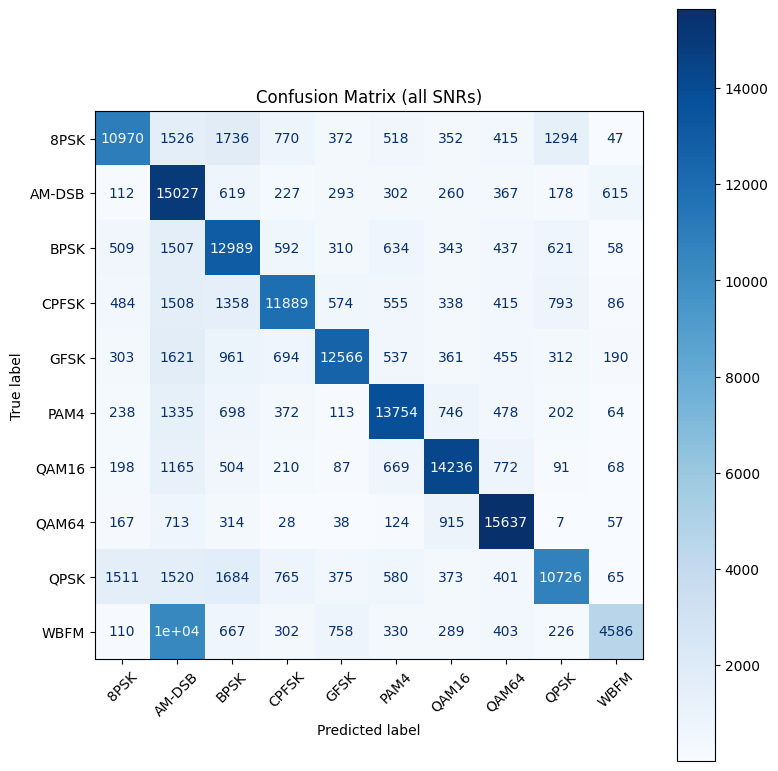

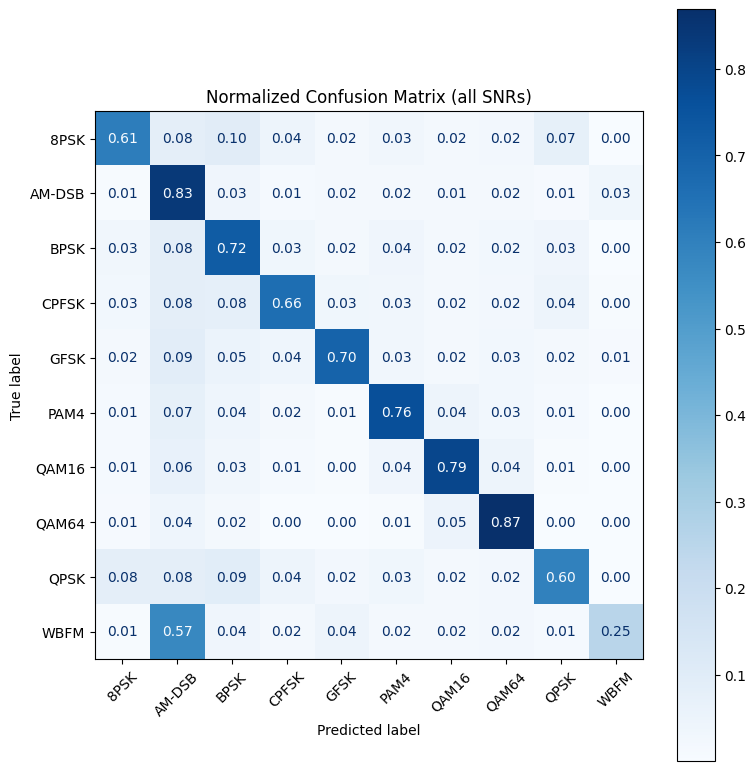

Per-SNR confusion matrices will be generated for SNRs: [-20. -18. -16. -14. -12. -10.  -8.  -6.  -4.  -2.   0.   2.   4.   6.
   8.  10.  12.  14.  16.  18.]


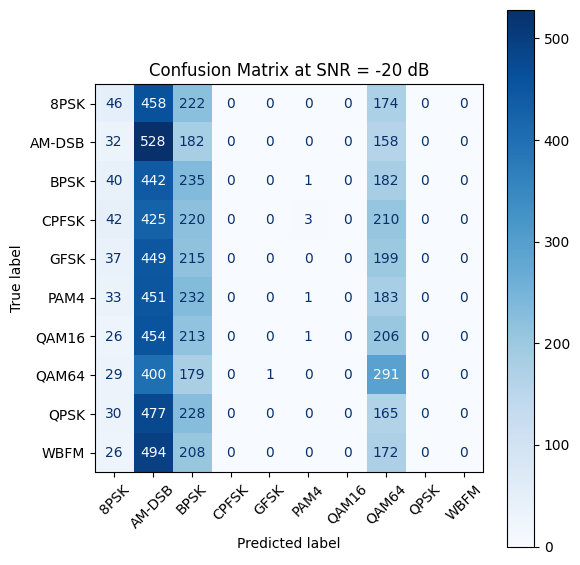

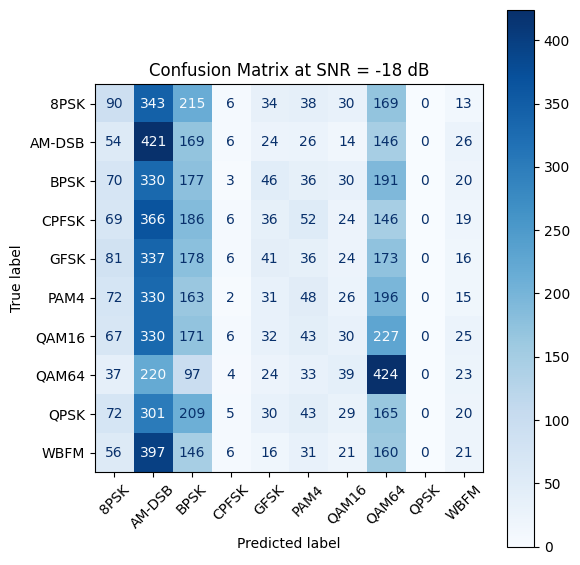

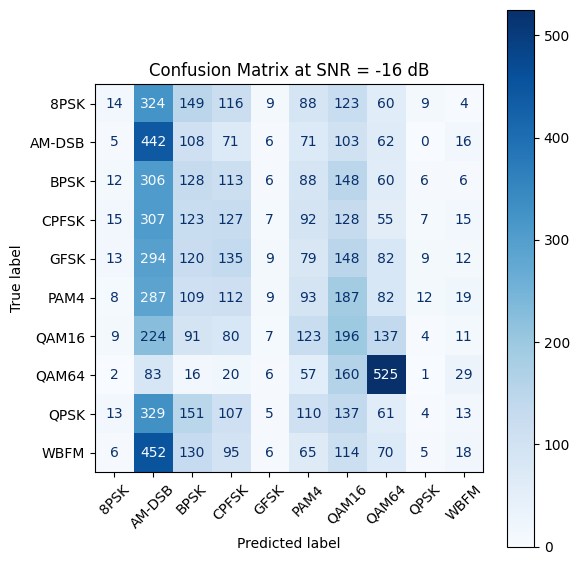

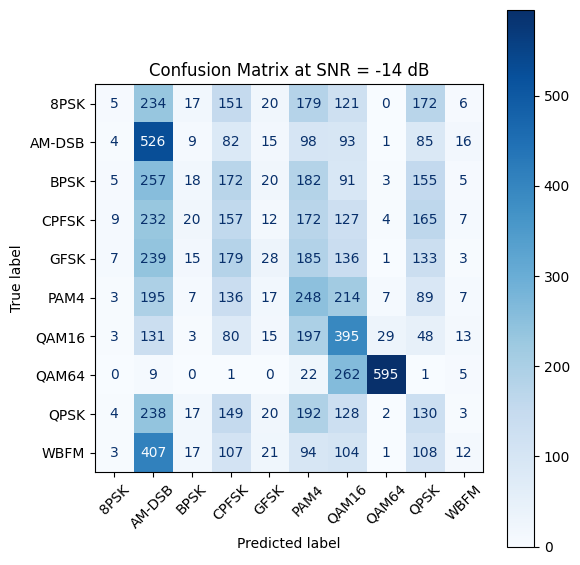

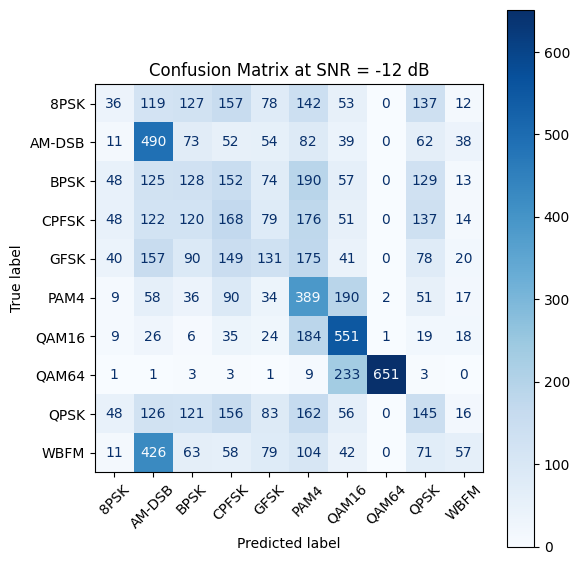

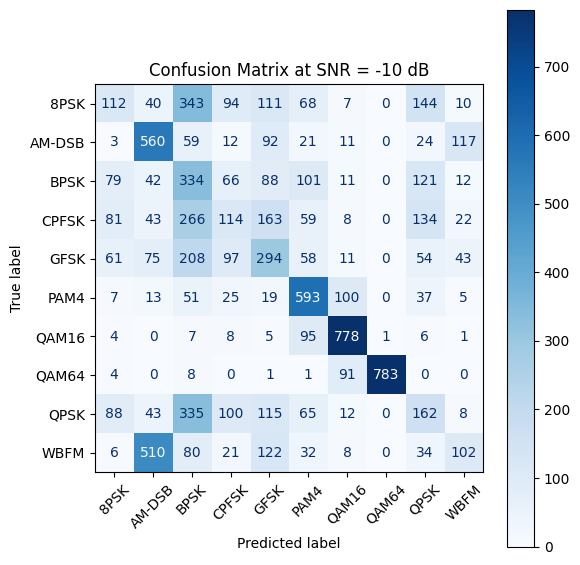

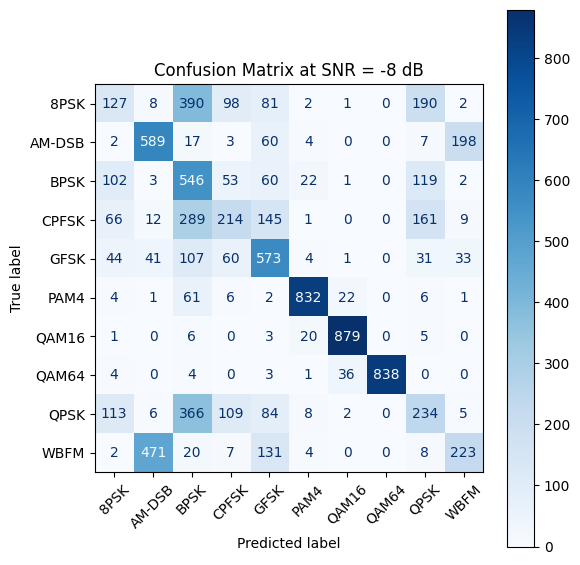

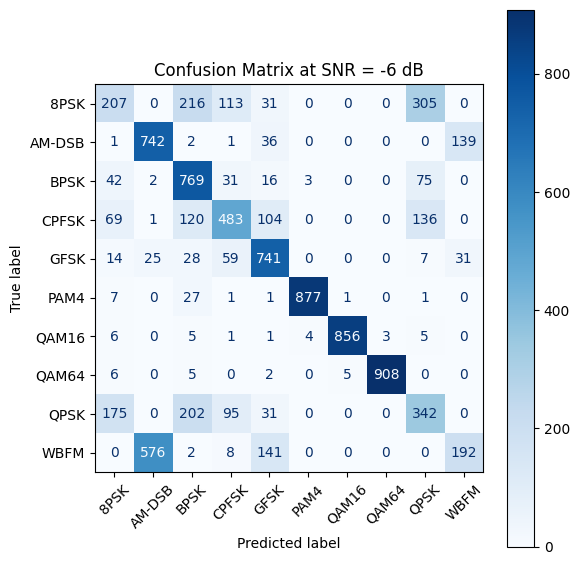

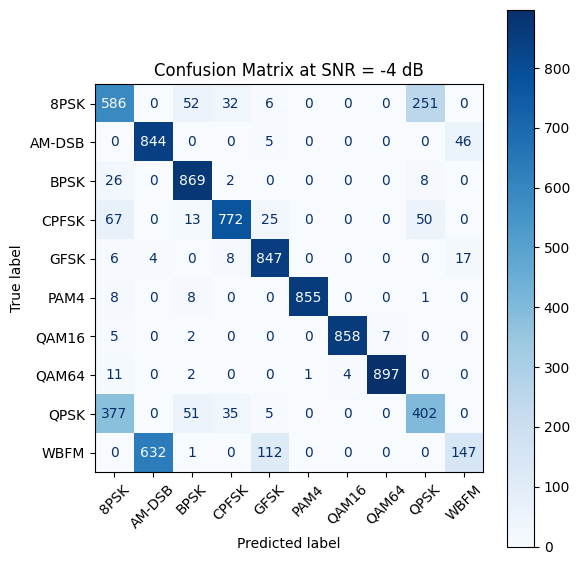

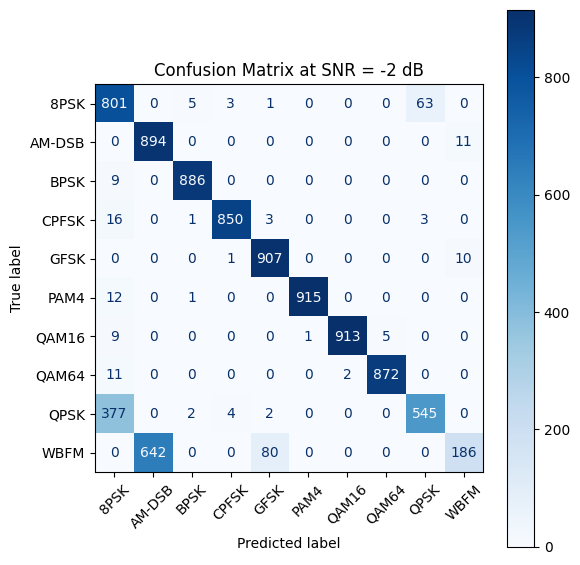

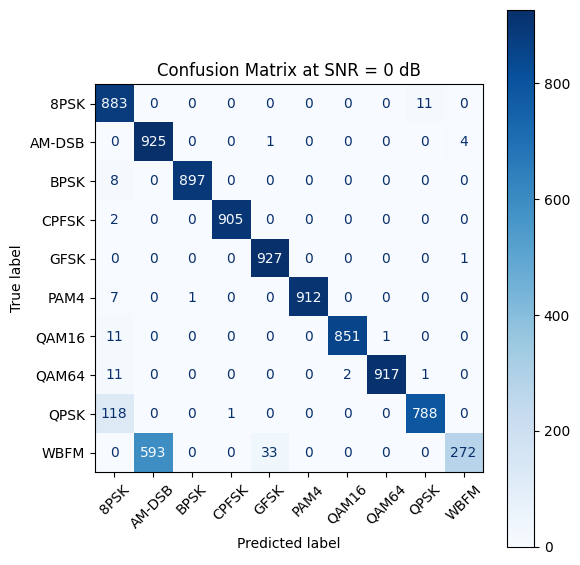

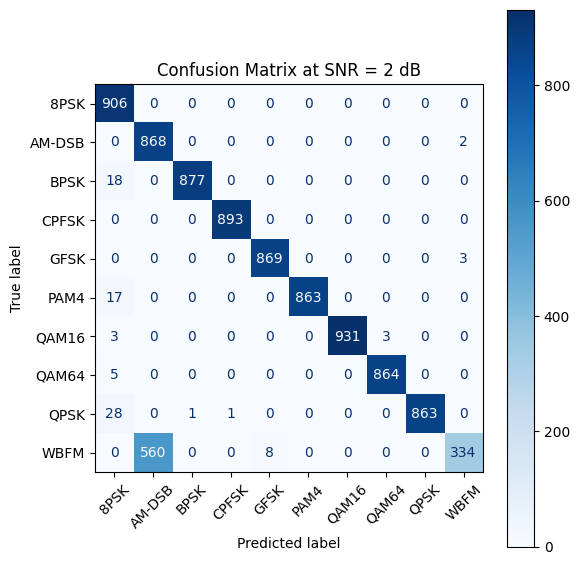

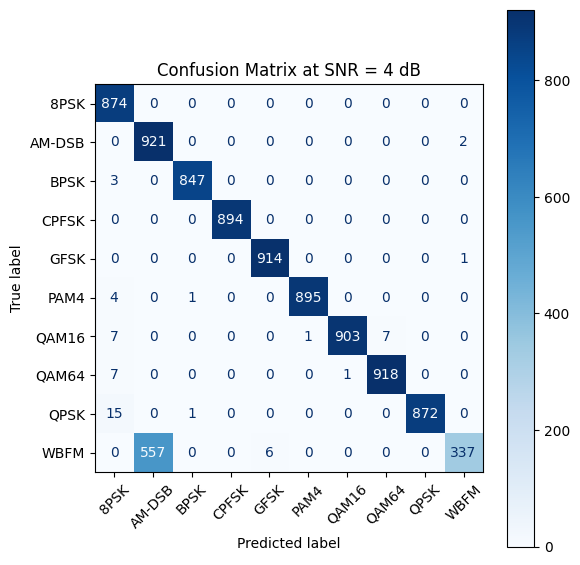

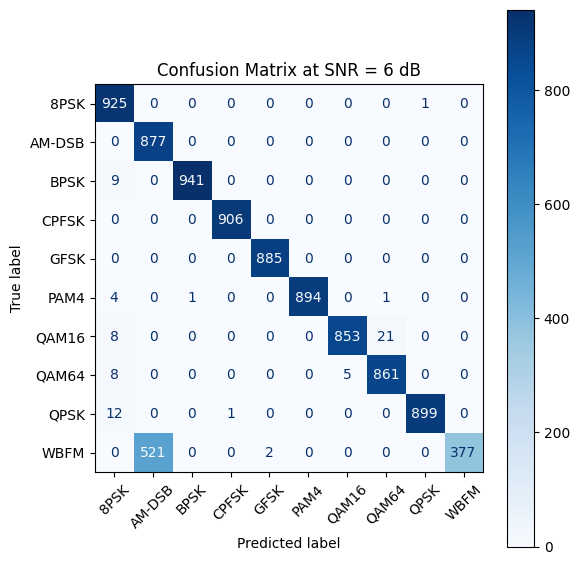

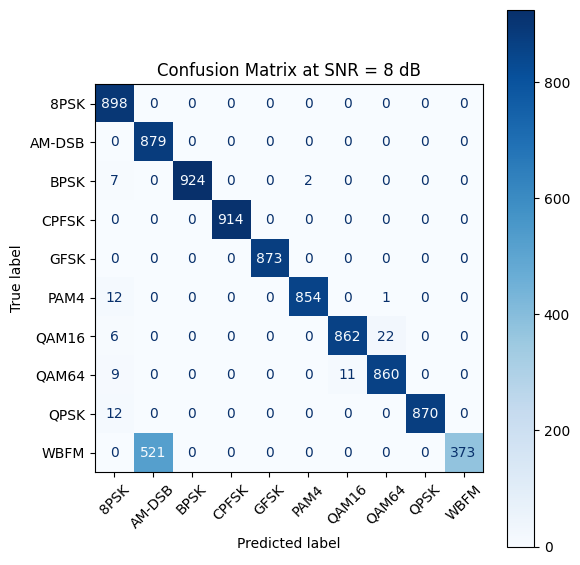

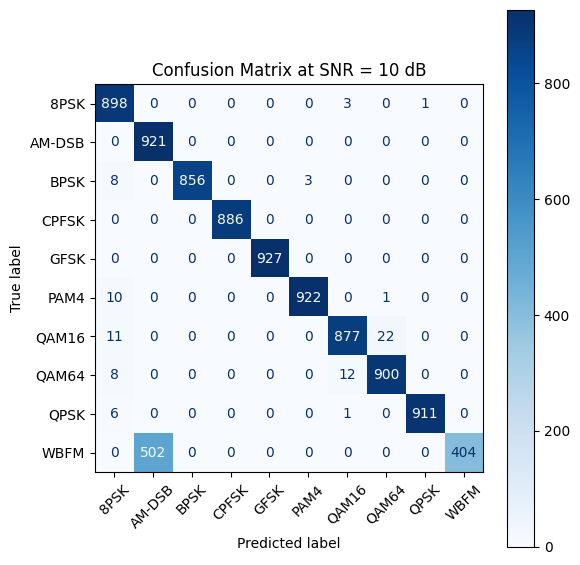

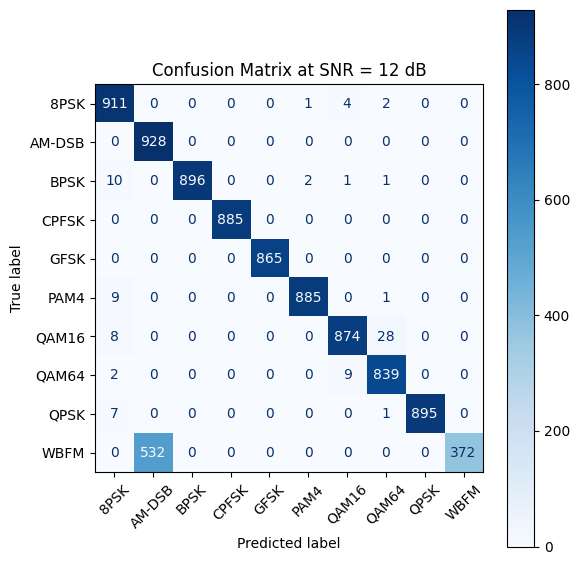

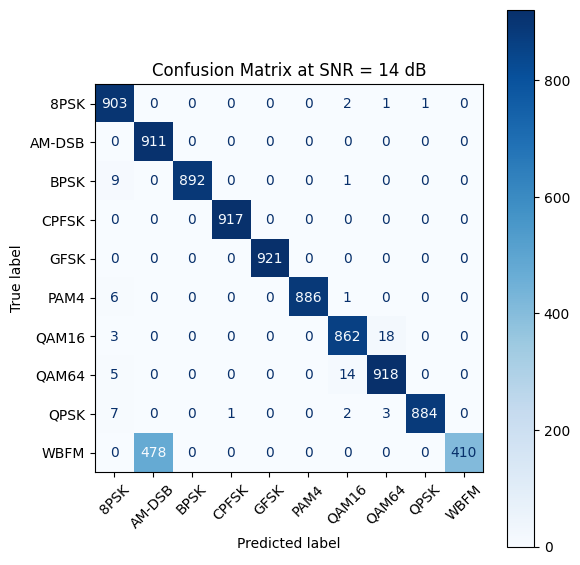

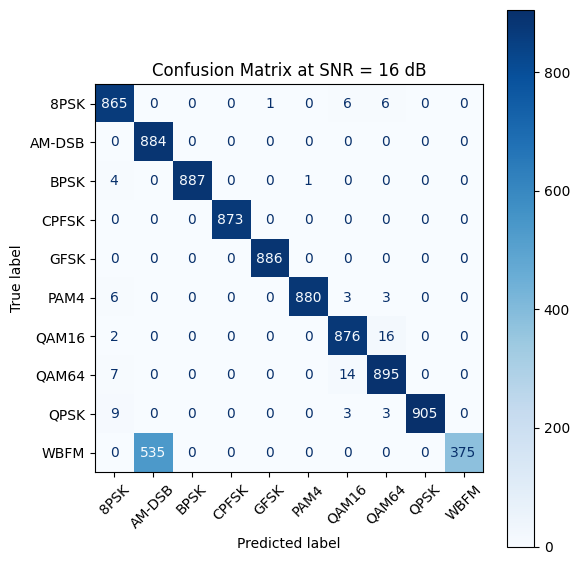

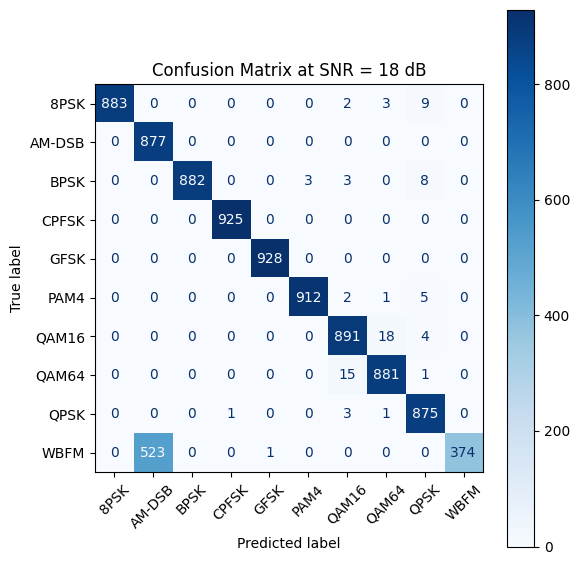

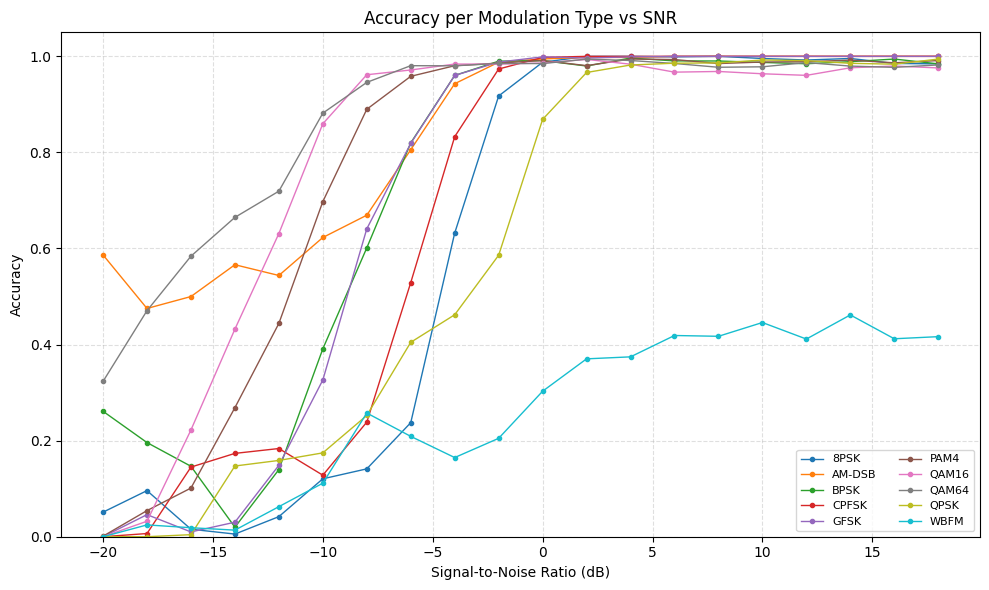

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# ----------------------------------------------------
# 1) Overall confusion matrix (all classes)
# ----------------------------------------------------
K = len(np.unique(y_true))          # number of classes

# If you have the modulation names list, put it here:
# e.g. for RML2016.10B:
mod_names = ['8PSK', 'AM-DSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
# otherwise just use string versions of the label indices:
#mod_names = [str(i) for i in range(K)]

cm = confusion_matrix(y_true, y_pred, labels=np.arange(K))

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=mod_names)
disp.plot(include_values=True, cmap="Blues", ax=ax, xticks_rotation=45)
ax.set_title("Confusion Matrix (all SNRs)")
plt.tight_layout()
plt.show()

# (Optional) normalized confusion matrix:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                              display_labels=mod_names)
disp.plot(include_values=True, cmap="Blues", ax=ax, xticks_rotation=45,
          values_format=".2f")
ax.set_title("Normalized Confusion Matrix (all SNRs)")
plt.tight_layout()
plt.show()


# ----------------------------------------------------
# 2) Confusion matrices per SNR (one figure per SNR)
# ----------------------------------------------------
snr_levels = np.unique(S_te.squeeze())
print("Per-SNR confusion matrices will be generated for SNRs:", snr_levels)

for s in snr_levels:
    mask_s = np.isclose(S_te.squeeze(), s)
    if mask_s.sum() == 0:
        continue

    cm_s = confusion_matrix(y_true[mask_s], y_pred[mask_s],
                            labels=np.arange(K))

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_s,
                                  display_labels=mod_names)
    disp.plot(include_values=True, cmap="Blues", ax=ax, xticks_rotation=45)
    ax.set_title(f"Confusion Matrix at SNR = {int(s)} dB")
    plt.tight_layout()
    # show or save:
    # plt.savefig(f"cm_snr_{int(s)}dB.png", dpi=200)
    plt.show()
    plt.close(fig)


# ----------------------------------------------------
# 3) Accuracy vs SNR per modulation type
#    (like the figure in the paper)
# ----------------------------------------------------
snr_levels = np.unique(S_te.squeeze())
snr_levels = np.sort(snr_levels)

# acc_mod_snr[c, i] = accuracy for class c at snr_levels[i]
acc_mod_snr = np.full((K, len(snr_levels)), np.nan, dtype=float)

for i, s in enumerate(snr_levels):
    mask_s = np.isclose(S_te.squeeze(), s)
    for c in range(K):
        mask_cs = mask_s & (y_true == c)
        if mask_cs.sum() == 0:
            continue
        acc_mod_snr[c, i] = (y_pred[mask_cs] == y_true[mask_cs]).mean()

plt.figure(figsize=(10, 6))
for c in range(K):
    # skip classes that have no samples at any SNR (shouldn't happen, but safe)
    if np.all(np.isnan(acc_mod_snr[c])):
        continue
    plt.plot(snr_levels,
             acc_mod_snr[c],
             marker=".",
             linewidth=1.0,
             label=mod_names[c])

plt.xlabel("Signal-to-Noise Ratio (dB)")
plt.ylabel("Accuracy")
plt.title("Accuracy per Modulation Type vs SNR")
plt.ylim(0.0, 1.05)
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend(loc="lower right", ncol=2, fontsize=8)  # adjust as you like
plt.tight_layout()
plt.show()
